2-column width: 180mm

1-column width: 88mm

All text should be sans-serif typeface, preferably Helvetica or Arial.

Maximum text size is 7pt. Minimum text size is 5pt.


In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math

import util

from plot_setup import *

FOLDER = "/Users/brendan/Projects/trails/data/"
datafiles = [
    "scenarios|2026-02-18/data.json",
    # just added this for (a).
    "example-fig|2025-12-12/data.json",
]

In [2]:
dfs = [
    util.load_data(FOLDER + datafile) for datafile in datafiles
]
df = pd.concat(dfs)
util.describe(df)

ratios: [50.0 200.0 100.0 400.0 800.0]
patch recovery: [0.001]
max costs: [2.0 4.0 8.0]
boundary conditions: ['PERIODIC' 'SOLID']
num locations: [8 16]
random walker seeds: 2
random locations seeds: 1
patch recovery logic: ['LINEAR']
settings.searchStrategy : ['KANAI_SUZUKI']
settings.scenario : ['RANDOM_DYNAMIC' 'CENTRAL_PLACE' 'WALL_TO_WALL' 'RANDOM_FIXED']
settings.X : [100 200]
steps: 40000
Index(['averageTravelCost', 'averageTravelLength', 'totalImprovement',
       'thresholdImprovement', 'steps', 'paths', 'weightedHeadings',
       'avgHeading', 'avgSquareHeading', 'patches', 'locations', 'walkers',
       'settings.patchImprovement', 'settings.patchRecovery',
       'settings.maxCost', 'settings.boundaryConditions',
       'settings.numLocations', 'settings.randomSeedWalkers',
       'settings.randomSeedLocations', 'settings.recoveryLogic',
       'settings.improvementLogic', 'settings.searchStrategy',
       'settings.scenario', 'settings.X', 'ratio'],
      dtype='object')


In [13]:
util.describe(df[df["settings.scenario"] == "RANDOM_FIXED"])

ratios: [100.0]
patch recovery: [0.001]
max costs: [2.0]
boundary conditions: ['SOLID']
num locations: [16]
random walker seeds: 1
random locations seeds: 1
patch recovery logic: ['LINEAR']
settings.searchStrategy : ['KANAI_SUZUKI']
settings.scenario : ['RANDOM_FIXED']
settings.X : [100]
steps: 40000
Index(['averageTravelCost', 'averageTravelLength', 'totalImprovement',
       'thresholdImprovement', 'steps', 'paths', 'weightedHeadings',
       'avgHeading', 'avgSquareHeading', 'patches', 'locations', 'walkers',
       'settings.patchImprovement', 'settings.patchRecovery',
       'settings.maxCost', 'settings.boundaryConditions',
       'settings.numLocations', 'settings.randomSeedWalkers',
       'settings.randomSeedLocations', 'settings.recoveryLogic',
       'settings.improvementLogic', 'settings.searchStrategy',
       'settings.scenario', 'settings.X', 'ratio'],
      dtype='object')


In [6]:
def plot_scenarios(
    subfig,
    title="",
    snapshots=[400, 800, 1600, 3200, 6400],
    scenario="RANDOM_DYNAMIC",
    cost=4.0,
    ratio=400,
    random_seed=1,
    X=200,
    boundary="SOLID",
    letter=None):
    _df = df[
        (df["settings.scenario"] == scenario) &
        (df["settings.maxCost"] == cost) &
        (df["ratio"] == ratio) &
        (df["settings.randomSeedWalkers"] == random_seed) &
        (df["settings.X"] == X) &
        (df["settings.boundaryConditions"] == boundary)
    ]

    
    # fig
    axs = subfig.subplots(1, len(snapshots))

    
    # if letter:
    #     add_letter(axs[0], -0.33, 12/mm_to_inch, letter)
        
    # , figsize=(180/mm_to_inch, 36/mm_to_inch))
    # plt.subplots_adjust(wspace=0.5, hspace=0.2)
    for i, steps in enumerate(snapshots):
        row = _df[(_df["steps"] == steps)].iloc[0]
        
        
        axs[i].imshow(np.reshape(row["patches"], (X, X)), cmap=CMAP, vmin=0, vmax=1.0)
        axs[i].axis('off')
    subfig.suptitle(title, fontsize=9)


,averageTravelCost,averageTravelLength,totalImprovement,thresholdImprovement,steps,paths,weightedHeadings,avgHeading,avgSquareHeading,patches,...,settings.boundaryConditions,settings.numLocations,settings.randomSeedWalkers,settings.randomSeedLocations,settings.recoveryLogic,settings.improvementLogic,settings.searchStrategy,settings.scenario,settings.X,ratio


IndexError: single positional indexer is out-of-bounds

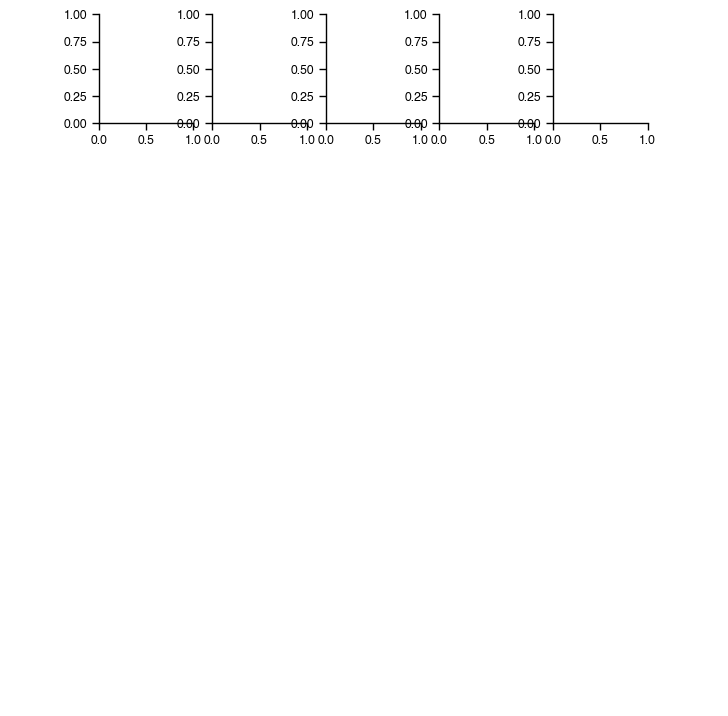

In [7]:
# Figure 6.

fig = plt.figure(figsize=(two_column_width, 5 * (36/mm_to_inch)))

all_figs = fig.subfigures(5, 1)

SNAPSHOTS = [400, 800, 1600, 3200, 6400]
X = 200


plot_scenarios(all_figs[0], scenario="RANDOM_FIXED", title="Random Fixed")

plot_scenarios(all_figs[1], scenario="CENTRAL_PLACE", title="Central Place")

plot_scenarios(all_figs[2], scenario="WALL_TO_WALL", title="Wall to Wall")

plot_scenarios(all_figs[3], scenario="RANDOM_DYNAMIC", title="All Random with Solid Boundaries")

plot_scenarios(all_figs[4], scenario="RANDOM_DYNAMIC", random_seed=2,
               boundary="PERIODIC", title="All Random with Periodic Boundaries")

for i, letter in enumerate(["a", "b", "c", "d", "e"]):
    add_letter(all_figs[i], 0.08, 0.5, letter)

fig.supxlabel("Time (Log Scale)", fontsize=FONTSIZE)

# fig.savefig("figures/6.pdf", bbox_inches="tight")
# fig.savefig("figures/6.svg", bbox_inches="tight")
# fig.savefig("figures/6.png", bbox_inches="tight")

In [6]:
def plot_nine(
    subfig,
    letter=None,
    steps=12800,
    scenario="RANDOM_DYNAMIC",
    random_seed=1,
    boundary="SOLID"):
    # fig, 
    axs = subfig.subplots(3, 3) #figsize=(80/mm_to_inch, 80/mm_to_inch))
    X = 200
    
    # if letter:
    #     add_letter(axs[0][0], -0.45, 18/mm_to_inch, letter)

    for r, ratio in enumerate([800, 400, 200]):
        for c, cost in enumerate([2.0, 4.0, 8.0]):
            # plot_scenarios(snapshots=[10000, 20000], X=200,
            #                ratio=ratio, cost=cost, boundary="SOLID", random_seed=1, scenario="RANDOM_DYNAMIC")
    
    
            _df = df[
                (df["settings.scenario"] == scenario) &
                (df["settings.maxCost"] == cost) &
                (df["ratio"] == ratio) &
                (df["settings.randomSeedWalkers"] == random_seed) &
                (df["settings.X"] == X) &
                (df["settings.boundaryConditions"] == boundary)
            ];
            row = _df[(_df["steps"] == steps)].iloc[0]
    
            axs[r][c].imshow(np.reshape(row["patches"], (X, X)), cmap=CMAP, vmin=0, vmax=1)
            axs[r][c].axis('off')
    # return fig


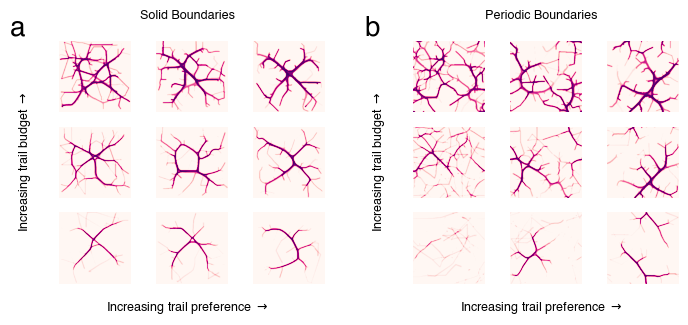

In [19]:
fig = fig = plt.figure(figsize=(two_column_width, 80/mm_to_inch))
left_fig, right_fig = fig.subfigures(1, 2)


STEPS = 12800
plot_nine(left_fig, random_seed=1, boundary="SOLID", steps=STEPS, letter="a")
left_fig.suptitle("Solid Boundaries", fontsize=9)
left_fig.supxlabel(r"Increasing trail preference $\rightarrow$", fontsize=9)
left_fig.supylabel(r"Increasing trail budget $\rightarrow$", fontsize=9)


plot_nine(right_fig, random_seed=2, boundary="PERIODIC", steps=STEPS, letter="b")
right_fig.suptitle("Periodic Boundaries", fontsize=9)
right_fig.supxlabel(r"Increasing trail preference $\rightarrow$", fontsize=9)
right_fig.supylabel(r"Increasing trail budget $\rightarrow$", fontsize=9)

add_letter(left_fig, 0, 0.9, "a")
add_letter(right_fig, 0, 0.9, "b")


# fig.savefig("figures/7.pdf", dpi=DPI, bbox_inches="tight")
fig.savefig("figures/7.svg", dpi=DPI, bbox_inches="tight")
fig.savefig("figures/7.png", dpi=DPI, bbox_inches="tight")